In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))


```mermaid
flowchart LR
    A[Train Detector] --> B[Crop Predicted Boxes]
    B --> C[Train ReID Classifier]
    C --> D[Sequential Accuracy + Speed]
    E[n10: Joint Backbone] -.compare.-> D
```


```mermaid
flowchart TD
    A[4 Cameras: cam_1..4] --> B[Images 4480x2800]
    A --> C[Labels: id cx cy w h]
    C --> D["id 1..16 = cow identity"]
    D --> E[Foreground class: detection/classification]
    D --> F[Identity class: re-ID]
    B --> G[Subsample by FRAME_STRIDE]
    G --> H[Drop empty frames]
    H --> I[Resize 640x400]
```


In [1]:
import random
from pathlib import Path

import torch

from n10_funs.config import (
    DEVICE, DATASET_NAME, DATA_ROOT, IMAGE_ROOT, LABEL_ROOT, CAMERAS,
    N_CLASSES, N_IDENTITIES, FRAME_STRIDE, MAX_SAMPLES, IMG_W, IMG_H,
    STRIDE, FEAT_W, FEAT_H, BATCH, check_dataset,
)

check_dataset()
print(f"{DATASET_NAME}: cameras={', '.join(CAMERAS)}")
print(DEVICE)


mmCows: cameras=cam_1, cam_2, cam_3, cam_4
cuda


In [2]:
### it is not like 10 identites are trained and 6 are tested, 
# it is like 16 identities are trained and tested,
# but the test set is not used for training, 
# it is only used for evaluation.

In [3]:
from n10_funs.loading_related_funs import load_frame_index, split_samples

ALL_SAMPLES = load_frame_index()
if not ALL_SAMPLES:
    raise RuntimeError(f"No labelled {DATASET_NAME} frames found under {DATA_ROOT}")
random.shuffle(ALL_SAMPLES)
print(f"total samples: {len(ALL_SAMPLES)}")
print(f"out of {len(ALL_SAMPLES)} samples, {len(ALL_SAMPLES) / len(CAMERAS):.1f} per camera")

TRAIN_SAMPLES, VAL_SAMPLES = split_samples(ALL_SAMPLES, MAX_SAMPLES)
if MAX_SAMPLES is not None:
    ALL_SAMPLES = ALL_SAMPLES[:MAX_SAMPLES]
print(f"selected {len(ALL_SAMPLES)} samples for training+validation (limit={MAX_SAMPLES})")

n_boxes_total = sum(len(b) for _, b in ALL_SAMPLES)
limit_text = "all" if MAX_SAMPLES is None else str(MAX_SAMPLES)
print(f"frames: {len(ALL_SAMPLES)} loaded (limit={limit_text}) -> {len(TRAIN_SAMPLES)} train / {len(VAL_SAMPLES)} val")
print(f"boxes:  {n_boxes_total} total, {n_boxes_total / len(ALL_SAMPLES):.1f} per frame")


cam_1: 1589 usable frames
cam_2: 1588 usable frames
cam_3: 1589 usable frames
cam_4: 1589 usable frames
total samples: 6355
out of 6355 samples, 1588.8 per camera
selected 500 samples for training+validation (limit=500)
frames: 500 loaded (limit=500) -> 425 train / 75 val
boxes:  5652 total, 11.3 per frame


In [4]:
from torch.utils.data import DataLoader

from n10_funs.dataset import MmCowsJointDataset, collate_joint

train_loader = DataLoader(MmCowsJointDataset(TRAIN_SAMPLES), batch_size=BATCH, shuffle=True,
                           collate_fn=collate_joint, num_workers=0)
val_loader = DataLoader(MmCowsJointDataset(VAL_SAMPLES), batch_size=BATCH, shuffle=False,
                         collate_fn=collate_joint, num_workers=0)

x0, hm0, off0, sz0, ctr0, id0, mask0 = next(iter(train_loader))
print("image batch:", x0.shape, " heatmap:", hm0.shape, " boxes/frame (padded):", off0.shape[1])


image batch: torch.Size([8, 3, 400, 640])  heatmap: torch.Size([8, 100, 160])  boxes/frame (padded): 15


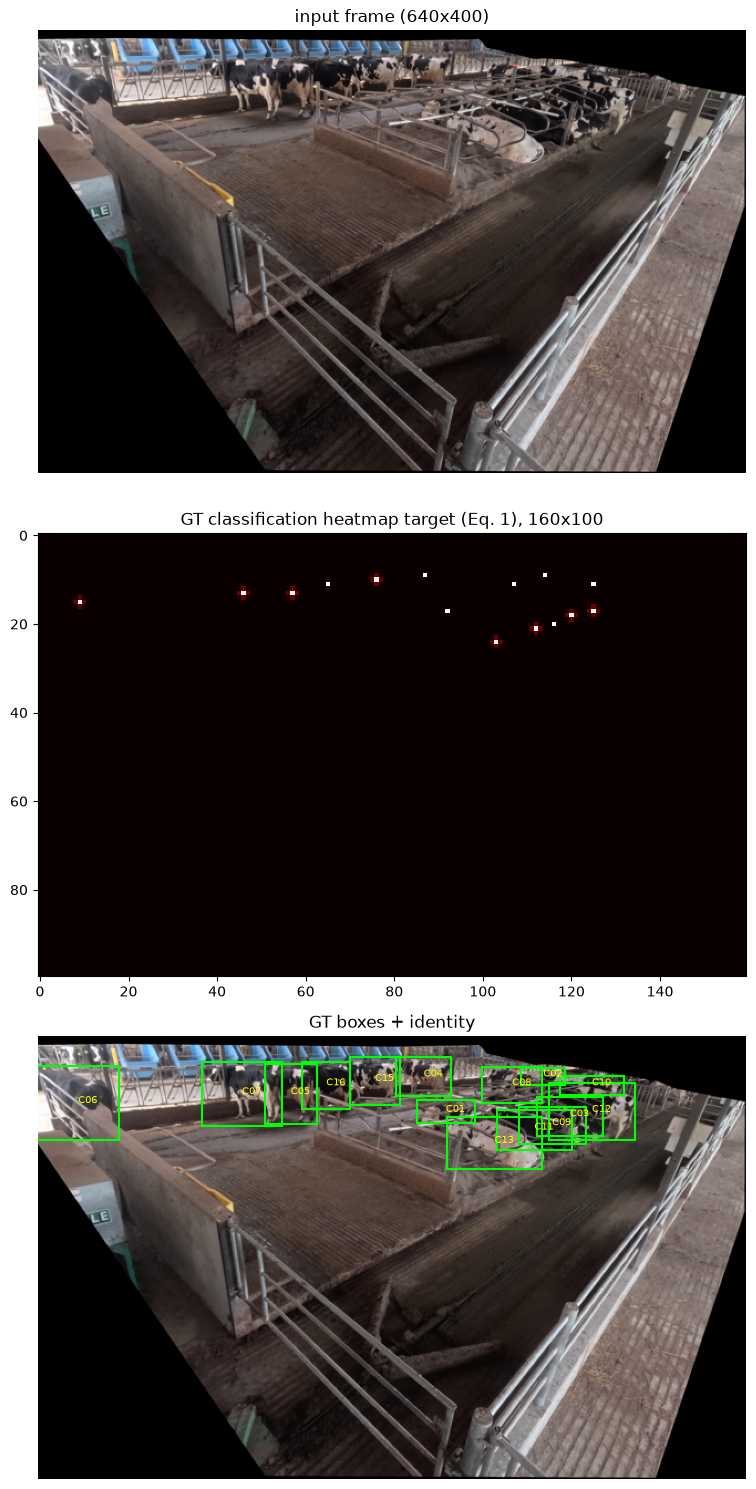

In [5]:
from n10_funs.viz import plot_batch_targets

plot_batch_targets(x0, hm0, ctr0, sz0, id0, STRIDE)


```mermaid
flowchart LR
    A[Data Index] --> B[Target Construction]
    B --> C[Decoder]
    C --> D[Backbone]
```


In [6]:
from n10_funs.model import count_params, show_shapes
from n10_funs.decode import decode_detections, box_iou


```mermaid
flowchart TD
    IMG[image] --> S["/4 stem"] --> D8["/8"] --> D16["/16"] --> D32["/32"]
    D32 --> U16[up + fuse]
    D16 --> U16
    U16 --> U8[up + fuse]
    D8 --> U8
    U8 --> U4[up + fuse back to /4]
    S --> U4
    U4 --> CLS[Classification head 1x1]
    U4 --> OFF[Detection: offset]
    U4 --> SIZE[Detection: size]
    U4 --> REID[Re-ID head 1x1]
    CLS --> OUT1[Foreground score]
    OFF --> OUT2[Sub-pixel center]
    SIZE --> OUT3[Box w,h]
    REID --> OUT4[128-d identity embedding]
```


In [7]:
from torch import nn
import torch.nn.functional as F

from n10_funs.model import ConvBNReLU, ResBlock, FuseUp, JointBackbone, make_head, JointDetReIDModel

model = JointDetReIDModel().to(DEVICE)
print("trainable parameters:", f"{count_params(model):,}")
show_shapes(model)


trainable parameters: 1,736,632
classification (1, 1, 100, 160)
offset     (1, 2, 100, 160)
size       (1, 2, 100, 160)
reid_map   (1, 128, 100, 160)


```mermaid
flowchart TD
    CLS[Classification loss: focal, Eq.1] --> TOT[L_total]
    DET[Detection loss: L1 offset+size, Eq.2] --> TOT
    REID[Re-ID loss: cross-entropy, Eq.3] --> TOT
    TOT --> W["Uncertainty weighting w1,w2,w3 (Eq.4/5)"]
```


In [8]:
from n10_funs.losses import focal_classification_loss, detection_l1_loss, joint_loss


```mermaid
flowchart LR
    A[model x] --> B[outputs]
    B --> C[joint_loss]
    C --> D[optimizer.zero_grad]
    D --> E[loss.backward]
    E --> F["optimizer.step (incl. w1,w2,w3)"]
```


In [9]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)  # paper's own optimizer + starting LR (Sec. 5.2)

x, hm, off, sz, ctr, ids, mask = next(iter(train_loader))
x, hm = x.to(DEVICE), hm.to(DEVICE)
off, sz, ctr = off.to(DEVICE), sz.to(DEVICE), ctr.to(DEVICE)
ids, mask = ids.to(DEVICE), mask.to(DEVICE)

model.train()
outputs = model(x)
loss, parts = joint_loss(model, outputs, hm, off, sz, ctr, ids, mask)
print("loss components before any training:", parts)

optimizer.zero_grad()
loss.backward()
optimizer.step()
print("\nsingle step ran cleanly -- gradients flowed through all 3 heads and log_vars.")


loss components before any training: {'classification': 203.5508270263672, 'off': 0.4185008406639099, 'size': 1.4017953872680664, 'identity': 2.7531588077545166, 'total': 69.37476348876953, 'w1': 0.0, 'w2': 0.0, 'w3': 0.0}

single step ran cleanly -- gradients flowed through all 3 heads and log_vars.


```mermaid
flowchart TD
    A[Adam lr=1e-4] --> B[Train Loop]
    B --> C[epoch]
    B --> D[total]
    B --> E[cls]
    B --> F[det]
    B --> G[re-id]
    B --> H[train_acc]
    B --> I[val_acc]
    B --> J[time]
    B --> K[lr]
```


In [10]:
from n10_funs.train import fit, evaluate_identity_head


In [11]:
# The shared-network training call from n10 is intentionally disabled here.
# The sequential detector and separate crop re-ID training are run in the n10b section at the end.
history = []

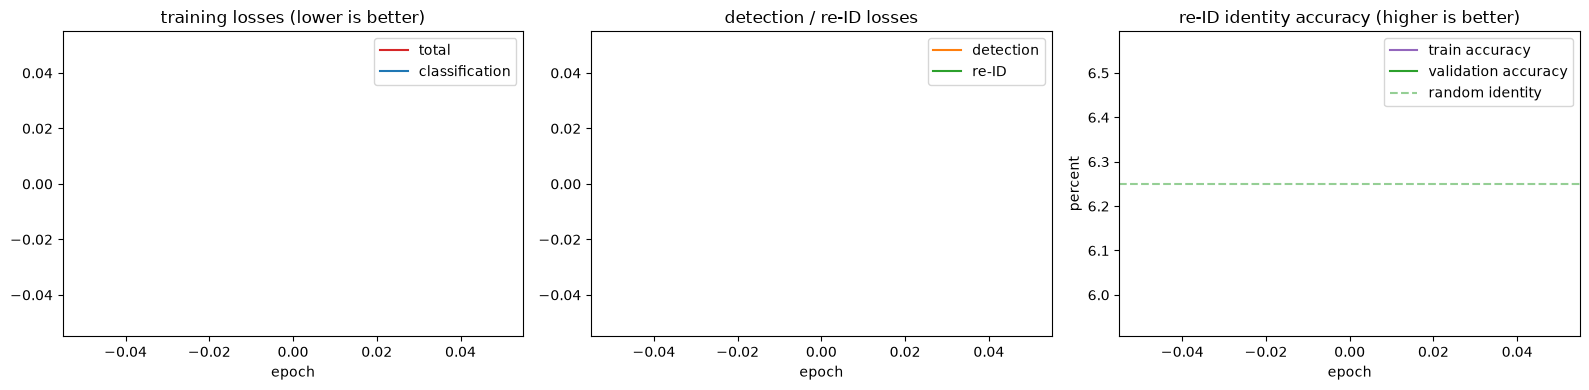


Final learned task weights (log_vars, Eq. 5 reorganized into 3 terms): [9.999999747378752e-05, 9.999999747378752e-05, 9.999999747378752e-05]
A more negative w_i means that task's loss is trusted/weighted more heavily.
A large positive w_i means the network has learned to downweight a noisy or hard task.


In [12]:
from n10_funs.viz import plot_history

plot_history(history)
print("\nFinal learned task weights (log_vars, Eq. 5 reorganized into 3 terms):",
      model.log_vars.detach().cpu().tolist())
print("A more negative w_i means that task's loss is trusted/weighted more heavily.")
print("A large positive w_i means the network has learned to downweight a noisy or hard task.")


```mermaid
flowchart TD
    A[Classification + Detection] --> B[decode_detections]
    B --> C[Match GT by IoU]
    C --> D["Precision/Recall @ IoU>=0.5"]
    E[Re-identification] --> F[Closed-set accuracy at GT centers]
```


In [13]:
from n10_funs.train import evaluate_detection

precision, recall, tp, fp, fn = evaluate_detection(model, val_loader)
id_acc = evaluate_identity_head(model, val_loader)
print(f"Classification+Detection (IoU>=0.5): precision={precision:.2%}  recall={recall:.2%}  (tp={tp}, fp={fp}, fn={fn})")
print(f"Identity accuracy (closed-set, 16 known cows): {id_acc:.1f}%  (random guess: {100/N_IDENTITIES:.1f}%)")


Classification+Detection (IoU>=0.5): precision=0.00%  recall=0.00%  (tp=0, fp=3000, fn=855)
Identity accuracy (closed-set, 16 known cows): 6.5%  (random guess: 6.2%)


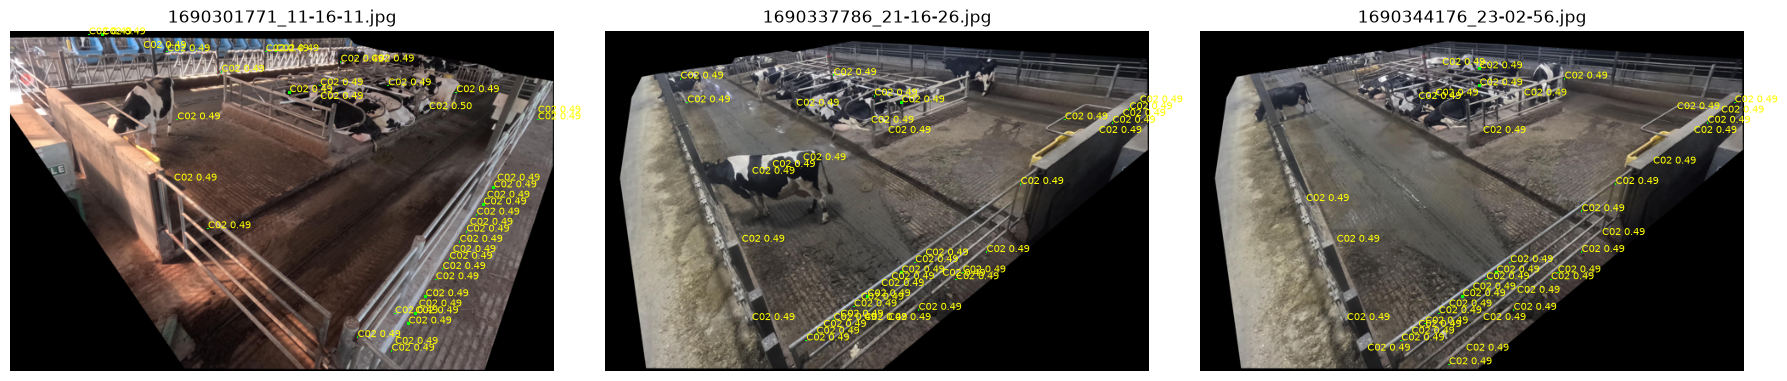

In [14]:
# Qualitative check: decoded detections + predicted identity on val frames.
from n10_funs.viz import predict_and_draw

predict_and_draw(model, VAL_SAMPLES, n_show=3)


```mermaid
flowchart LR
    A[Anchor-free detection] --- B[Classification head]
    B --- C[Heatmap]
    C --- D[Gaussian radius]
    D --- E[Homoscedastic uncertainty weighting]
    E --- F[Closed-set vs open-set identification]
    F --- G[IDA-Up / feature fusion]
```


```mermaid
flowchart TD
    A[Turn off uncertainty weighting] --> Z[Next Steps]
    B[Add geometric augmentation] --> Z
    C[Swap to DeformConv2d] --> Z
    D[Increase reid_dim 128->512] --> Z
    E[Online association: Kalman + Hungarian] --> Z
    F[Held-out-camera split] --> Z
    G[Optional: behavior head] --> Z
```


```mermaid
flowchart LR
    A[Trained Model] --> B[runs/n10_joint_det_reid/]
    C[Validation Metrics] --> B
```


In [15]:
from n10_funs.checkpoint import save_checkpoint

save_checkpoint(model, history)


saved and verified mmCows model + history to runs\n10_joint_det_reid\model.pt


WindowsPath('runs/n10_joint_det_reid/model.pt')

```mermaid
flowchart TD
    A[Shared Helper Cells] --> B[Train Detector no re-ID loss]
    B --> C[Create labelled crops from predictions]
    C --> D[Train crop classifier]
    D --> E[Report accuracy + sequential timing]
```


In [16]:
from n10_funs.sequential_detector import DetectorOnlyModel, detector_loss

detector = DetectorOnlyModel().to(DEVICE)
print("detector-only trainable parameters:", f"{count_params(detector):,}")
show_shapes(detector)


detector-only trainable parameters: 1,707,749
classification (1, 1, 100, 160)
offset     (1, 2, 100, 160)
size       (1, 2, 100, 160)


In [17]:
from n10_funs.sequential_detector import fit_detector

DETECTOR_EPOCHS = 15
detector_history = fit_detector(detector, train_loader, val_loader, epochs=DETECTOR_EPOCHS)


epoch   1/15  | total   67.357 | cls   65.683 | det    1.674 | val_precision    0.0% | val_recall    0.0% | time    55.5s | lr 1.0e-04 | gpu    1317MB
epoch   2/15  | total    9.936 | cls    8.474 | det    1.461 | val_precision    0.0% | val_recall    0.0% | time    52.6s | lr 1.0e-04 | gpu     733MB
epoch   3/15  | total    5.371 | cls    4.099 | det    1.273 | val_precision    0.0% | val_recall    0.0% | time    53.8s | lr 1.0e-04 | gpu     733MB
epoch   4/15  | total    4.042 | cls    2.936 | det    1.106 | val_precision    0.0% | val_recall    0.0% | time    51.2s | lr 1.0e-04 | gpu     734MB
epoch   5/15  | total    3.394 | cls    2.422 | det    0.972 | val_precision    0.0% | val_recall    0.0% | time    50.9s | lr 1.0e-04 | gpu     734MB
epoch   6/15  | total    3.008 | cls    2.151 | det    0.857 | val_precision    0.0% | val_recall    0.0% | time    51.2s | lr 1.0e-04 | gpu     733MB
epoch   7/15  | total    2.751 | cls    1.984 | det    0.767 | val_precision    0.0% | val_rec

In [18]:

detector_precision, detector_recall, det_tp, det_fp, det_fn = evaluate_detection(detector, val_loader)
print(f"Stage 1 (detector-only) validation detection @ IoU>=0.5: "
      f"precision={detector_precision:.2%}  recall={detector_recall:.2%}  (tp={det_tp}, fp={det_fp}, fn={det_fn})")


Stage 1 (detector-only) validation detection @ IoU>=0.5: precision=68.45%  recall=13.45%  (tp=115, fp=53, fn=740)


In [19]:
from n10_funs.reid_crops import CROP_H, CROP_W, generate_crops

train_crops, train_crop_labels = generate_crops(detector, TRAIN_SAMPLES)
val_crops, val_crop_labels = generate_crops(detector, VAL_SAMPLES)
print(f"Stage 2 crop dataset (from detector predictions, IoU>=0.5 matched to GT identity):")
print(f"  train: {len(train_crops)} crops (from {len(TRAIN_SAMPLES)} frames)")
print(f"  val:   {len(val_crops)} crops (from {len(VAL_SAMPLES)} frames)")
assert len(train_crops) > 0 and len(val_crops) > 0, (
    'Detector produced 0 matched crops -- Stage 2 has nothing to train on. This happens when the '
    'detector has not trained long enough yet (raise DETECTOR_EPOCHS / MAX_SAMPLES above and re-run '
    'from the detector-training cell) or when score_thresh/iou_thresh here are too strict for its '
    'current predictions.'
)


Stage 2 crop dataset (from detector predictions, IoU>=0.5 matched to GT identity):
  train: 848 crops (from 425 frames)
  val:   117 crops (from 75 frames)


In [20]:
from n10_funs.reid_crops import CropDataset, CropIdentityClassifier

CROP_BATCH = 16
train_crop_loader = DataLoader(CropDataset(train_crops, train_crop_labels), batch_size=CROP_BATCH,
                                shuffle=True, num_workers=0)
val_crop_loader = DataLoader(CropDataset(val_crops, val_crop_labels), batch_size=CROP_BATCH,
                              shuffle=False, num_workers=0)

reid_classifier = CropIdentityClassifier().to(DEVICE)
print("Stage 2 (crop identity classifier) trainable parameters:", f"{count_params(reid_classifier):,}")


Stage 2 (crop identity classifier) trainable parameters: 294,704


In [21]:
from n10_funs.reid_crops import fit_reid_crops

REID_EPOCHS = 15
reid_history = fit_reid_crops(reid_classifier, train_crop_loader, val_crop_loader, epochs=REID_EPOCHS)


epoch   1/15  | loss   2.714 | train_acc    9.7% | val_acc   12.0% | time    1.7s | gpu     374MB
epoch   2/15  | loss   2.634 | train_acc   13.1% | val_acc   15.4% | time    0.9s | gpu     223MB
epoch   3/15  | loss   2.599 | train_acc   16.6% | val_acc   14.5% | time    0.9s | gpu     223MB
epoch   4/15  | loss   2.557 | train_acc   17.6% | val_acc   19.7% | time    0.8s | gpu     223MB
epoch   5/15  | loss   2.523 | train_acc   20.9% | val_acc   18.8% | time    0.8s | gpu     223MB
epoch   6/15  | loss   2.482 | train_acc   21.1% | val_acc   17.9% | time    0.8s | gpu     223MB
epoch   7/15  | loss   2.473 | train_acc   24.2% | val_acc   19.7% | time    0.8s | gpu     223MB
epoch   8/15  | loss   2.447 | train_acc   23.8% | val_acc   23.1% | time    0.9s | gpu     223MB
epoch   9/15  | loss   2.417 | train_acc   26.2% | val_acc   23.1% | time    0.9s | gpu     223MB
epoch  10/15  | loss   2.392 | train_acc   27.9% | val_acc   26.5% | time    0.8s | gpu     223MB
epoch  11/15  | loss

In [22]:
from n10_funs.reid_crops import sequential_pipeline_timing

seq_seconds_per_frame, n_frames, n_boxes = sequential_pipeline_timing(detector, reid_classifier, VAL_SAMPLES)
final_val_id_acc = reid_history[-1]["val_acc"] if reid_history else 0.0

print("=== n10b sequential pipeline: final validation numbers ===")
print(f"Stage 1 detection  @ IoU>=0.5: precision={detector_precision:.2%}  recall={detector_recall:.2%}")
print(f"Stage 2 identity accuracy (on detector-matched crops): {final_val_id_acc:.1f}%  "
      f"(random guess: {100/N_IDENTITIES:.1f}%)")
print(f"End-to-end sequential inference: {seq_seconds_per_frame*1000:.1f} ms/frame "
      f"over {n_frames} val frames ({n_boxes} crops total)")
print()
print("Compare against n10 (`runs/n10_joint_det_reid/`), which runs ONE forward pass through a")
print("single shared backbone with 3 heads for the same classification+detection+identity outputs.")
print("This cell only measures this notebook's own timing -- load n10's saved history/model.pt")
print("separately to compare accuracy and ms/frame side by side.")


=== n10b sequential pipeline: final validation numbers ===
Stage 1 detection  @ IoU>=0.5: precision=68.45%  recall=13.45%
Stage 2 identity accuracy (on detector-matched crops): 27.4%  (random guess: 6.2%)
End-to-end sequential inference: 18.8 ms/frame over 75 val frames (168 crops total)

Compare against n10 (`runs/n10_joint_det_reid/`), which runs ONE forward pass through a
single shared backbone with 3 heads for the same classification+detection+identity outputs.
This cell only measures this notebook's own timing -- load n10's saved history/model.pt
separately to compare accuracy and ms/frame side by side.


In [23]:
from n10_funs.reid_crops import save_sequential_checkpoint

save_sequential_checkpoint(detector, reid_classifier, detector_history, reid_history)


saved sequential detector + reid classifier + histories + config to runs\n10b_sequential\pipeline.pt


WindowsPath('runs/n10b_sequential/pipeline.pt')